# 05_figures — Epistasis results visualization (FLU / PULV)

Inputs:
- data/epi_<drug>_<run>_annotated.tsv

Outputs:
- figures/<DRUG>/
- tables/<DRUG>/

In [23]:
from pathlib import Path

DRUG = "FLU"        # "FLU" or "PULV"
RUN_LABEL = "qtl"    # qtl, all, etc.

BASE_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis")
DATA_DIR = BASE_DIR / "data"

IN_TSV = DATA_DIR / f"epi_{DRUG.lower()}_{RUN_LABEL}_annotated.tsv"

FIG_DIR = BASE_DIR / "figures" / DRUG
TAB_DIR = BASE_DIR / "tables" / DRUG
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("IN_TSV:", IN_TSV)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

IN_TSV: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/data/epi_flu_qtl_annotated.tsv
FIG_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/FLU
TAB_DIR: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/tables/FLU


## 2) Load annotated epistasis table

In [24]:
import pandas as pd
import numpy as np

epi = pd.read_csv(IN_TSV, sep="\t")
print("Loaded:", epi.shape)
print("Columns:", list(epi.columns))
display(epi.head())

Loaded: (21325, 15)
Columns: ['CHR1', 'SNP1', 'CHR2', 'SNP2', 'BETA_INT', 'STAT', 'P', 'SNP1_Chromosome', 'SNP1_Position (bp)', 'SNP1_gene_name', 'SNP1_gene_standard_name', 'SNP2_Chromosome', 'SNP2_Position (bp)', 'SNP2_gene_name', 'SNP2_gene_standard_name']


,CHR1,SNP1,CHR2,SNP2,BETA_INT,STAT,P,SNP1_Chromosome,SNP1_Position (bp),SNP1_gene_name,SNP1_gene_standard_name,SNP2_Chromosome,SNP2_Position (bp),SNP2_gene_name,SNP2_gene_standard_name
0,5,snp10459,7,snp14392,-0.006083,28.8020,8.035000e-08,5,367674,YER105C,NUP157,7,461612,YGL016W,KAP122
1,5,snp10459,7,snp14393,-0.006106,29.0187,7.184000e-08,5,367674,YER105C,NUP157,7,461695,YGL016W,KAP122
2,5,snp10459,7,snp14394,-0.006078,28.7570,8.223000e-08,5,367674,YER105C,NUP157,7,461875,YGL016W,KAP122
3,5,snp10459,7,snp14395,-0.006168,29.6159,5.279000e-08,5,367674,YER105C,NUP157,7,462190,YGL016W,KAP122
4,5,snp10459,7,snp14396,-0.006168,29.6159,5.279000e-08,5,367674,YER105C,NUP157,7,462196,YGL016W,KAP122


## 3) Basic QC summaries

In [26]:
# Ensure numeric
for c in ["BETA_INT", "STAT", "P"]:
    if c in epi.columns:
        epi[c] = pd.to_numeric(epi[c], errors="coerce")

print("Rows:", len(epi))
print("P-value min:", epi["P"].min(), "max:", epi["P"].max())
print("Non-missing BETA_INT:", epi["BETA_INT"].notna().mean())
print("Non-missing STAT:", epi["STAT"].notna().mean())

# Annotation coverage if present
for col in ["SNP1_Position (bp)", "SNP2_Position (bp)", "SNP1_gene_name", "SNP2_gene_name"]:
    if col in epi.columns:
        print(f"{col}: {epi[col].notna().mean():.3f} non-missing")

Rows: 21325
P-value min: 4.622e-133 max: 0.0001
Non-missing BETA_INT: 1.0
Non-missing STAT: 1.0
SNP1_Position (bp): 1.000 non-missing
SNP2_Position (bp): 1.000 non-missing
SNP1_gene_name: 1.000 non-missing
SNP2_gene_name: 1.000 non-missing


## 4) Top hits table (by P-value)

In [27]:
TOP_N = 100

cols_pref = [
    "CHR1", "SNP1", "SNP1_Chromosome", "SNP1_Position (bp)", "SNP1_gene_name", "SNP1_gene_standard_name",
    "CHR2", "SNP2", "SNP2_Chromosome", "SNP2_Position (bp)", "SNP2_gene_name", "SNP2_gene_standard_name",
    "BETA_INT", "STAT", "P"
]
cols = [c for c in cols_pref if c in epi.columns]

top = epi.sort_values("P", ascending=True).head(TOP_N)[cols].copy()
out_top = TAB_DIR / f"top_{TOP_N}_pairs_{DRUG.lower()}_{RUN_LABEL}.tsv"
top.to_csv(out_top, sep="\t", index=False)

print("Saved:", out_top)
display(top.head(5))

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/tables/FLU/top_100_pairs_flu_qtl.tsv


,CHR1,SNP1,SNP1_Chromosome,SNP1_Position (bp),SNP1_gene_name,SNP1_gene_standard_name,CHR2,SNP2,SNP2_Chromosome,SNP2_Position (bp),SNP2_gene_name,SNP2_gene_standard_name,BETA_INT,STAT,P
13614,7,snp14442,7,472821,YGL012W,ERG4,14,snp34732,14,467214,YNL085W,MKT1,0.033153,602.769,4.622000e-133
13613,7,snp14442,7,472821,YGL012W,ERG4,14,snp34731,14,467023,YNL085W,MKT1,0.033142,602.588,5.060000e-133
13472,7,snp14441,7,472609,YGL012W,ERG4,14,snp34732,14,467214,YNL085W,MKT1,0.033130,602.021,6.724000e-133
13471,7,snp14441,7,472609,YGL012W,ERG4,14,snp34731,14,467023,YNL085W,MKT1,0.033119,601.840,7.362000e-133
13330,7,snp14440,7,472372,YGL013C,PDR1,14,snp34732,14,467214,YNL085W,MKT1,0.033114,601.499,8.729000e-133


## 5) Interaction Manhattan (pair genomic position)

We assign each SNP a genome-wide coordinate and plot each interaction pair as:
x = midpoint of the two SNP coordinates
y = -log10(P)

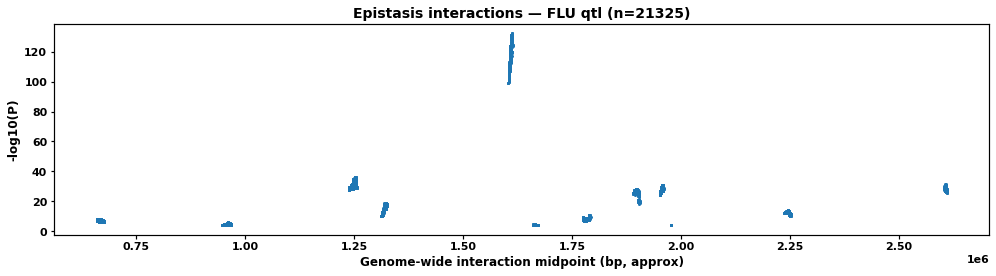

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/FLU/manhattan_pair_midpoint_flu_qtl.png


In [28]:
import matplotlib.pyplot as plt

# Build per-chromosome offsets from SNP metadata if present
# Fall back to using CHR1/CHR2 + positions only.
req_cols = ["CHR1", "CHR2", "P"]
pos1 = "SNP1_Position (bp)" if "SNP1_Position (bp)" in epi.columns else None
pos2 = "SNP2_Position (bp)" if "SNP2_Position (bp)" in epi.columns else None

assert pos1 is not None and pos2 is not None, (
    "Missing SNP1_Position (bp) / SNP2_Position (bp) in annotated TSV. "
    "Re-check 04_plink_analysis.ipynb merges."
)

df = epi[["CHR1", "CHR2", pos1, pos2, "P"]].dropna().copy()
df["CHR1"] = df["CHR1"].astype(int)
df["CHR2"] = df["CHR2"].astype(int)
df[pos1] = df[pos1].astype(float)
df[pos2] = df[pos2].astype(float)
df["neglog10P"] = -np.log10(df["P"].astype(float))

# Estimate chrom lengths from observed SNP positions (good enough for plotting)
chroms = sorted(set(df["CHR1"]).union(set(df["CHR2"])))
chr_max = {}
for ch in chroms:
    m1 = df.loc[df["CHR1"] == ch, pos1].max() if (df["CHR1"] == ch).any() else 0
    m2 = df.loc[df["CHR2"] == ch, pos2].max() if (df["CHR2"] == ch).any() else 0
    chr_max[ch] = float(np.nanmax([m1, m2]))

offset = {}
running = 0.0
for ch in chroms:
    offset[ch] = running
    running += chr_max[ch] + 1e5  # small spacer

df["gpos1"] = df.apply(lambda r: offset[r["CHR1"]] + r[pos1], axis=1)
df["gpos2"] = df.apply(lambda r: offset[r["CHR2"]] + r[pos2], axis=1)
df["midpoint"] = (df["gpos1"] + df["gpos2"]) / 2.0

plt.figure(figsize=(14, 4))
plt.scatter(df["midpoint"], df["neglog10P"], s=4)
plt.xlabel("Genome-wide interaction midpoint (bp, approx)")
plt.ylabel("-log10(P)")
plt.title(f"Epistasis interactions — {DRUG} {RUN_LABEL} (n={len(df)})")
out_png = FIG_DIR / f"manhattan_pair_midpoint_{DRUG.lower()}_{RUN_LABEL}.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

## 6) Chromosome-pair heatmap (counts of significant interactions)

Counts interactions where P <= P_THRESH, grouped by (CHR1, CHR2).

Significant interactions: 21325 at P <= 0.0001


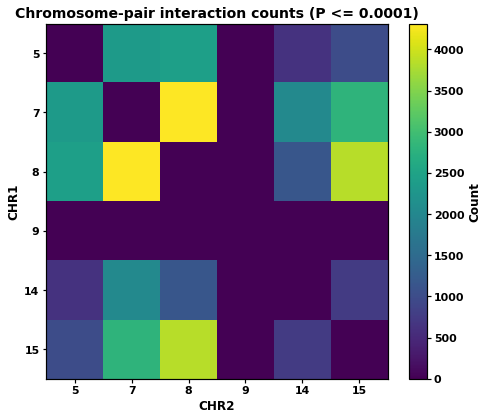

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/FLU/chrpair_heatmap_P0.0001_flu_qtl.png
Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/tables/FLU/chrpair_counts_P0.0001_flu_qtl.tsv


In [29]:
import matplotlib.pyplot as plt

P_THRESH = 1e-4

df = epi[["CHR1", "CHR2", "P"]].dropna().copy()
df["CHR1"] = df["CHR1"].astype(int)
df["CHR2"] = df["CHR2"].astype(int)
df["P"] = df["P"].astype(float)

sig = df[df["P"] <= P_THRESH].copy()
print("Significant interactions:", sig.shape[0], "at P <=", P_THRESH)

# Symmetrize counts (chrA, chrB) == (chrB, chrA)
a = sig[["CHR1", "CHR2"]].copy()
b = sig.rename(columns={"CHR1": "CHR2", "CHR2": "CHR1"})[["CHR1", "CHR2"]]
pairs = pd.concat([a, b], ignore_index=True)

mat = pairs.groupby(["CHR1", "CHR2"]).size().unstack(fill_value=0)

# Ensure square matrix for consistent plotting (chr 1..16 typical)
chrs = sorted(set(mat.index).union(set(mat.columns)))
mat = mat.reindex(index=chrs, columns=chrs, fill_value=0)

plt.figure(figsize=(7, 6))
plt.imshow(mat.values, aspect="auto")
plt.xticks(range(len(chrs)), chrs)
plt.yticks(range(len(chrs)), chrs)
plt.xlabel("CHR2")
plt.ylabel("CHR1")
plt.title(f"Chromosome-pair interaction counts (P <= {P_THRESH})")
plt.colorbar(label="Count")
out_png = FIG_DIR / f"chrpair_heatmap_P{P_THRESH:g}_{DRUG.lower()}_{RUN_LABEL}.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

out_tsv = TAB_DIR / f"chrpair_counts_P{P_THRESH:g}_{DRUG.lower()}_{RUN_LABEL}.tsv"
mat.to_csv(out_tsv, sep="\t")
print("Saved:", out_tsv)

## 7) Gene–gene interaction edge list (for Cytoscape)

We convert SNP pairs to gene pairs (using gene_standard_name if available).
Filters:
- P <= P_THRESH
- gene names must be present on both sides

In [30]:
P_THRESH = 1e-4

# Choose best gene label columns available
g1 = "SNP1_gene_standard_name" if "SNP1_gene_standard_name" in epi.columns else "SNP1_gene_name"
g2 = "SNP2_gene_standard_name" if "SNP2_gene_standard_name" in epi.columns else "SNP2_gene_name"

if g1 not in epi.columns or g2 not in epi.columns:
    raise ValueError("Gene annotation columns missing; confirm 04_plink_analysis.ipynb created gene columns.")

edges = epi[[g1, g2, "BETA_INT", "STAT", "P"]].copy()
edges = edges.dropna(subset=[g1, g2, "P"])
edges[g1] = edges[g1].astype(str).str.strip().replace({"": np.nan})
edges[g2] = edges[g2].astype(str).str.strip().replace({"": np.nan})
edges = edges.dropna(subset=[g1, g2])

edges = edges[edges["P"].astype(float) <= P_THRESH].copy()

# Normalize order so A-B == B-A
a = edges[[g1, g2]].min(axis=1)
b = edges[[g1, g2]].max(axis=1)
edges["geneA"] = a
edges["geneB"] = b

# Collapse multiple SNP-SNP edges into gene-gene summary
agg = edges.groupby(["geneA", "geneB"]).agg(
    n_edges=("P", "size"),
    minP=("P", "min"),
    mean_abs_beta=("BETA_INT", lambda x: np.nanmean(np.abs(pd.to_numeric(x, errors="coerce")))),
    mean_stat=("STAT", lambda x: np.nanmean(pd.to_numeric(x, errors="coerce")))
).reset_index().sort_values("minP")

out_edges = TAB_DIR / f"gene_gene_edges_P{P_THRESH:g}_{DRUG.lower()}_{RUN_LABEL}.tsv"
agg.to_csv(out_edges, sep="\t", index=False)

print("Saved:", out_edges)
display(agg.head(5))

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/tables/FLU/gene_gene_edges_P0.0001_flu_qtl.tsv


,geneA,geneB,n_edges,minP,mean_abs_beta,mean_stat
75,ERG4,MKT1,28,4.622000e-133,0.032724,584.786964
217,MKT1,PDR1,52,8.729000e-133,0.032684,583.434615
82,ERG4,SNN1,7,4.742000e-131,0.032685,585.307857
269,PDR1,SNN1,13,8.918000e-131,0.032659,584.438154
85,ERG4,TCB2,70,3.767000e-127,0.031123,538.465229


## 8) Quick gene–gene network plot (top edges)
This is a quick visualization; for serious network work, use Cytoscape with the exported edge list.

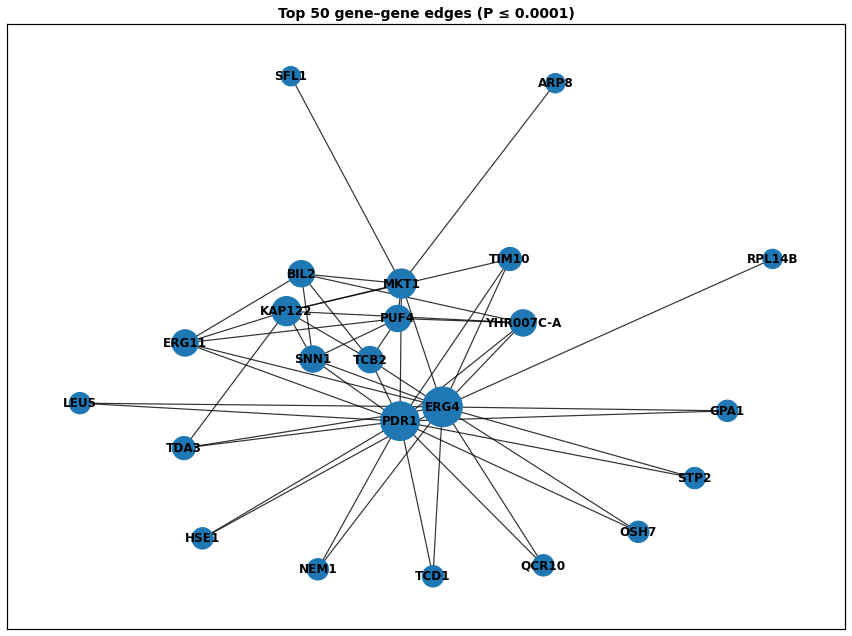

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/FLU/gene_network_top50_P0.0001_flu_qtl.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import networkx as nx
except ImportError:
    raise ImportError("networkx not installed in this env. Either install it or skip this cell.")

TOP_EDGES = 50
LABEL_FONT_SIZE = 12     # increase this (was ~8 before)
NODE_BASE_SIZE = 300     # base node size
NODE_SCALE = 80          # scaling by degree

plot_edges = agg.head(TOP_EDGES).copy()

G = nx.Graph()
for _, r in plot_edges.iterrows():
    G.add_edge(r["geneA"], r["geneB"], weight=-np.log10(r["minP"]))

plt.figure(figsize=(12, 9))

# Layout
pos = nx.spring_layout(G, seed=1, k=1.2)

# Node sizes by degree
deg = dict(G.degree())
node_sizes = [NODE_BASE_SIZE + NODE_SCALE * deg[n] for n in G.nodes()]

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.8)

# Draw labels with larger font
nx.draw_networkx_labels(
    G,
    pos,
    font_size=LABEL_FONT_SIZE,
    font_weight="bold"
)

plt.title(
    f"Top {TOP_EDGES} gene–gene edges (P ≤ {P_THRESH:g})",
    fontsize=14
)

out_png = FIG_DIR / f"gene_network_top{TOP_EDGES}_P{P_THRESH:g}_{DRUG.lower()}_{RUN_LABEL}.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

## 9) Top gene–gene epistatic interactions bar plot (like Fluconazole figure)

X-axis: Max -log10(P) among SNP pairs for each gene–gene pair  
(Computed as -log10(minP) across SNP pairs mapping to that gene pair)

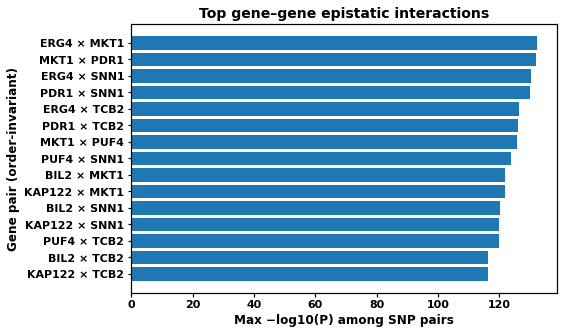

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/5_epistasis/figures/FLU/top_gene_gene_bar_flu_qtl_top15.png


In [32]:
import numpy as np
import matplotlib.pyplot as plt

TOP_K = 15  # number of gene-gene pairs to show

# Ensure we have the aggregated gene-gene table from the earlier cell
# Required columns: geneA, geneB, minP
req = {"geneA", "geneB", "minP"}
missing_cols = req - set(agg.columns)
if missing_cols:
    raise ValueError(f"agg is missing required columns: {missing_cols}. Run the gene–gene aggregation cell first.")

plot_df = agg.copy()
plot_df["score"] = -np.log10(plot_df["minP"].astype(float))

# Order labels like "GENE1 × GENE2"
plot_df["pair"] = plot_df["geneA"].astype(str) + " × " + plot_df["geneB"].astype(str)

plot_df = plot_df.sort_values("score", ascending=False).head(TOP_K)
plot_df = plot_df.iloc[::-1]  # reverse for nice top-to-bottom ordering in barh

plt.figure(figsize=(8, 4.8))
plt.barh(plot_df["pair"], plot_df["score"])
plt.xlabel("Max −log10(P) among SNP pairs")
plt.ylabel("Gene pair (order-invariant)")
plt.title(f"Top gene–gene epistatic interactions")
plt.tight_layout()

out_png = FIG_DIR / f"top_gene_gene_bar_{DRUG.lower()}_{RUN_LABEL}_top{TOP_K}.png"
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)